Import Required Libraries

Introduction:
The used car market depends on several factors such as car specifications, usage history, and seller details. Accurately predicting the selling price of a used car helps both buyers and sellers make informed decisions.
This case study aims to build a supervised machine learning regression model to predict the selling price of used cars based on available features.

Objective

The objective of this study is to:
Analyze the factors affecting used car prices
Preprocess the dataset for machine learning
Build a regression model to predict car prices
Evaluate the performance of the model using suitable metrics.

In [2]:
#import pandas for data handling (tables, CSV files)
import pandas as pd

#import numpy for numerical operations
import numpy as np

#import matplotlib for basic plotting
import matplotlib.pyplot as plt

#import seaborn for advanced data visualization
import seaborn as sns

#import function to split data into training and testing sets
from sklearn.model_selection import train_test_split

#import LabelEncoder to convert categorical text data into numbers
from sklearn.linear_model import LinearRegression

#import Linear Regression model
from sklearn.linear_model import LinearRegression

#import metrics to evaluate model performance
from sklearn.metrics import mean_squared_error, r2_score

Dataset Description
The dataset contains the following attributes: 
• Make – Manufacturer of the car 
• Model – Model name of the car 
• Price – Selling price of the car (in INR) 
• Year – Year of manufacture 
• Kilometer – Distance travelled by the car (in km) 
• Fuel Type – Type of fuel used (Petrol, Diesel, CNG, Electric, etc.) 
• Transmission – Manual or Automatic 
• Location – City or region where the car is listed 
• Color – Exterior color of the car 
• Seller Type – Individual or Dealer 
• Engine – Engine capacity (cc) 
• Owner – Ownership status (First Owner, Second Owner, etc.) 
• Max Power – Maximum power output 
• Max Torque – Maximum torque output 
• Drivetrain – Type of drivetrain (FWD, RWD, AWD) 
• Length – Length of the car (mm) 
• Width – Width of the car (mm) 
• Height – Height of the car (mm) 
• Seating Capacity – Number of seats 
• Fuel Tank Capacity – Fuel tank capacity (litres)

LOAD THE DATASET

In [6]:
#read the CSV file and store it in a DataFrame
df=pd.read_csv("car details v4.csv")

#display first 5 rows of the dataset
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [7]:
#display number of rows and columns
df.shape

(2059, 20)

In [8]:
#show column names,data types,and non null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

EXPLORATORY DATA ANALYSIS (EDA)

Exploratory Data Analysis(EDA) was performed to understand the dataset.

Distribution of car prices was analyzed using histograms
Relationships between price and features such as year and kilometers were visualized using scatter plots
A correlation heatmap was used to identify relationships between numerical variables.

Observation:
Newer cars generally have higher prices
Cars with higher mileage tend to have lower prices

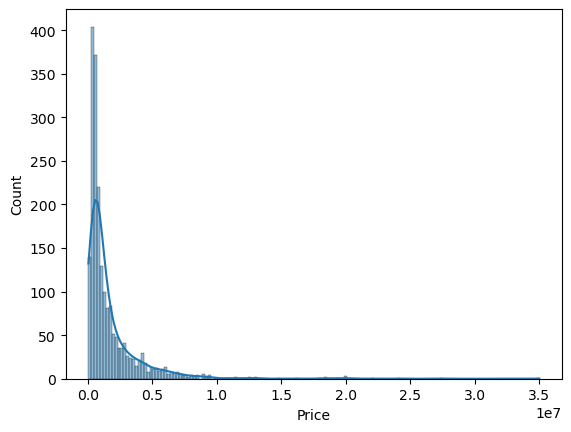

In [12]:
#PRICE DISTRIBUTION

#plot the distribution of car prices
sns.histplot(df['Price'],kde=True)

#display the plot
plt.show()

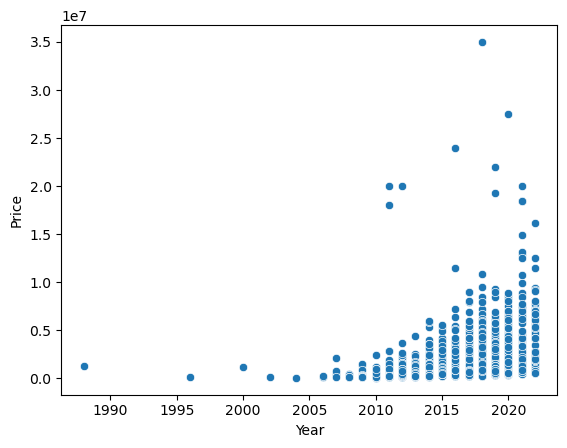

In [13]:
#PRICE VS YEAR

#scatter plot to show relationship between year and price
sns.scatterplot(x=df['Year'],y=df['Price'])

#display the ploy
plt.show()

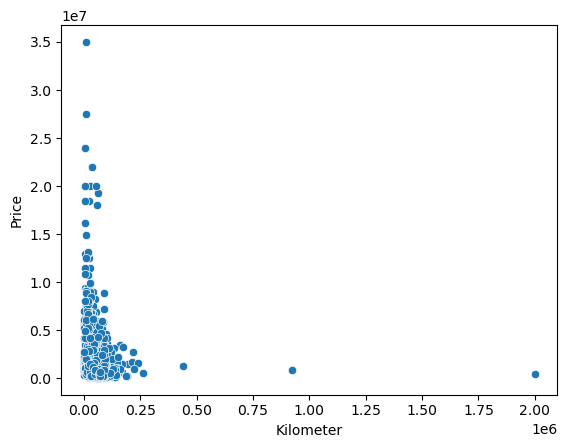

In [14]:
#PRICE VS KILOMETER

#Scatter plot to show relationship between Kilometer and Price
sns.scatterplot(x=df['Kilometer'],y=df['Price'])

#display the plot
plt.show()

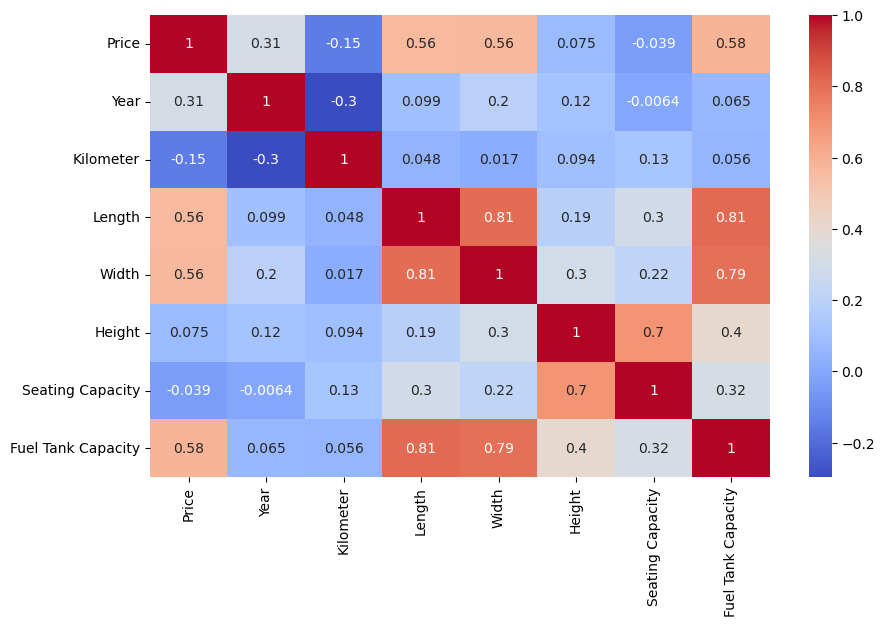

In [18]:
#CORRELATION HEATMAP

#select only numeric columns from the DataFrame
numeric_df = df.select_dtypes(include=['int64', 'float64'])

#create a figure with fixed size
plt.figure(figsize=(10,6))

#plot correlation heatmap for numeric feature
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

#display the plot
plt.show()

DATA PREPROCESSING

To prepare the data for modeling, the following steps were performed:

Handle missing values

Missing numerical values were filled using the median
Missing categorical values were filled with a placeholder value

In [19]:
#Check how many missing values are present in column

df.isnull().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

In [20]:
#fill missing numeric values with median of each column
df.fillna(df.median(numeric_only=True), inplace=True)

#fill missing categorical values with the word 'Unknown'
df.fillna("Unknown", inplace=True)


In [21]:
df.isnull().sum()

Make                  0
Model                 0
Price                 0
Year                  0
Kilometer             0
Fuel Type             0
Transmission          0
Location              0
Color                 0
Owner                 0
Seller Type           0
Engine                0
Max Power             0
Max Torque            0
Drivetrain            0
Length                0
Width                 0
Height                0
Seating Capacity      0
Fuel Tank Capacity    0
dtype: int64

Encode Categorical Variables

Categorical features such as fuel type and transmission were converted into numeric form using Label Encoding

In [23]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
#create LabelEncoder object
le=LabelEncoder()

#select all categorical (object type) columns
cat_cols=df.select_dtypes(include='object').columns

#convert each categorical column into numeric form
for col in cat_cols:
    df[col]=le.fit_transform(df[col])

In [24]:
df.dtypes

Make                    int64
Model                   int64
Price                   int64
Year                    int64
Kilometer               int64
Fuel Type               int64
Transmission            int64
Location                int64
Color                   int64
Owner                   int64
Seller Type             int64
Engine                  int64
Max Power               int64
Max Torque              int64
Drivetrain              int64
Length                float64
Width                 float64
Height                float64
Seating Capacity      float64
Fuel Tank Capacity    float64
dtype: object

In [25]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [26]:
#display statistical summary of all columns
#this helps to see different ranges of numerical features
df.describe()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2059.000000,2059.000000,2.059000e+03,2059.000000,2.059000e+03,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000
mean,15.039339,526.496357,1.702992e+06,2016.425449,5.422471e+04,3.799903,0.550267,32.214667,10.463332,1.465274,1.967460,43.748422,188.116561,138.950947,1.155901,4283.631374,1768.054395,1590.282661,5.296746,51.892326
std,9.170870,308.230213,2.419881e+06,3.363564,5.736172e+04,2.059320,0.497588,19.286686,5.379296,0.925890,0.190671,33.349896,110.001723,89.035044,0.726747,435.799127,133.146412,134.186875,0.811029,14.696588
min,0.000000,0.000000,4.900000e+04,1988.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,8.000000,256.500000,4.849990e+05,2014.000000,2.900000e+04,2.000000,0.000000,15.000000,6.000000,1.000000,2.000000,13.000000,78.000000,56.500000,1.000000,3986.000000,1695.000000,1485.000000,5.000000,42.000000
50%,18.000000,514.000000,8.250000e+05,2017.000000,5.000000e+04,2.000000,1.000000,32.000000,14.000000,1.000000,2.000000,40.000000,194.000000,131.000000,1.000000,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,21.000000,809.500000,1.925000e+06,2019.000000,7.200000e+04,6.000000,1.000000,45.000000,15.000000,1.000000,2.000000,64.000000,304.000000,207.500000,1.000000,4620.000000,1831.000000,1672.000000,5.000000,60.000000
max,32.000000,1049.000000,3.500000e+07,2022.000000,2.000000e+06,8.000000,1.000000,76.000000,16.000000,5.000000,2.000000,108.000000,335.000000,290.000000,3.000000,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [32]:
#display first 5 rows of selected numerical columns
#this shows that features are on different scales
df[['Year', 'Kilometer', 'Engine']].head()

,Year,Kilometer,Engine
0,0.170858,0.574133,-1.102173
1,-0.721270,0.362268,-1.042188
2,-1.613398,0.222769,-1.132165
3,0.765609,-0.291637,-1.132165
4,0.468234,0.257644,0.487424


FEATURE SCALING

Numerical features were scaled using StandardScaler
This ensured all features had similar ranges and improved model performance

In [33]:
#import StandardScaler to standardize numerical features
from sklearn.preprocessing import StandardScaler

#create a StandardScaler object
scaler = StandardScaler()

#select all feature columns except the target variable 'Price'
num_cols = df.drop('Price', axis=1).columns

# apply scaling so that features have mean = 0 and standard deviation = 1
df[num_cols] = scaler.fit_transform(df[num_cols])

In [29]:
df[num_cols].describe()
# Display statistical summary after scaling

,Make,Model,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03,2.059000e+03
mean,-1.725456e-18,-1.518401e-16,1.693794e-14,-4.486185e-17,1.294092e-16,7.592006e-17,-1.656438e-16,1.535656e-16,-5.003822e-17,-3.312875e-16,3.192093e-17,3.882276e-17,-1.138801e-16,-7.074369e-17,-1.380365e-17,1.621929e-16,1.928197e-16,1.156055e-16,-2.898766e-16
std,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00,1.000243e+00
min,-1.640302e+00,-1.708542e+00,-8.453045e+00,-9.455415e-01,-1.845671e+00,-1.106138e+00,-1.670712e+00,-1.945584e+00,-1.582942e+00,-1.032109e+01,-1.312119e+00,-1.710539e+00,-1.561011e+00,-1.590900e+00,-2.718957e+00,-2.201528e+00,-3.170101e+00,-4.065878e+00,-2.510875e+00
25%,-7.677624e-01,-8.761696e-01,-7.212703e-01,-4.398550e-01,-8.742403e-01,-1.106138e+00,-8.927842e-01,-8.299257e-01,-5.026378e-01,1.707019e-01,-9.222185e-01,-1.001287e+00,-9.262755e-01,-2.145709e-01,-6.831213e-01,-5.488105e-01,-7.847879e-01,-3.659769e-01,-6.732671e-01
50%,3.229115e-01,-4.055213e-02,1.708576e-01,-7.366830e-02,-8.742403e-01,9.040460e-01,-1.113304e-02,6.576191e-01,-5.026378e-01,1.707019e-01,-1.124241e-01,5.349796e-02,-8.932301e-02,-2.145709e-01,1.982326e-01,1.461607e-02,-3.375417e-01,-3.659769e-01,-1.287909e-01
75%,6.501137e-01,9.183798e-01,7.656095e-01,3.099559e-01,1.068621e+00,9.040460e-01,6.630708e-01,8.435622e-01,-5.026378e-01,1.707019e-01,6.073931e-01,1.053725e+00,7.700980e-01,-2.145709e-01,7.720308e-01,4.728696e-01,6.091295e-01,-3.659769e-01,5.518045e-01
max,1.849855e+00,1.695585e+00,1.657737e+00,3.392939e+01,2.040051e+00,9.040460e-01,2.270788e+00,1.029505e+00,3.818578e+00,1.707019e-01,1.927058e+00,1.335607e+00,1.696924e+00,2.538087e+00,2.950169e+00,3.395175e+00,3.016805e+00,3.333924e+00,3.614484e+00


In [30]:
# Display first 5 rows after scaling
df[num_cols].head()

,Make,Model,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,-0.876830,-1.364560,0.170858,0.574133,1.068621,0.904046,1.233551,-0.643983,-0.502638,-5.075196,-1.102173,1.126469,-1.504840,-0.214571,-0.673941,-0.661496,-0.635706,-0.365977,-1.149684
1,0.431979,0.894041,-0.721270,0.362268,-0.874240,0.904046,0.403762,0.843562,1.657970,0.170702,-1.042188,0.917331,-0.695973,-0.214571,-0.662465,-0.548810,-0.263001,-0.365977,-0.673267
2,-0.767762,1.633928,-1.613398,0.222769,1.068621,0.904046,0.351900,-0.458040,-0.502638,0.170702,-1.132165,1.026446,-1.437434,-0.214571,-1.603494,-1.300046,-0.300271,-0.365977,-1.149684
3,1.631720,-0.111945,0.765609,-0.291637,1.068621,0.904046,0.455623,0.471676,-0.502638,0.170702,-1.132165,1.062818,-1.392497,-0.214571,-0.662465,-0.173193,-0.598435,-0.365977,-1.013565
4,1.631720,0.069782,0.468234,0.257644,-0.874240,0.904046,0.663071,-0.643983,-0.502638,0.170702,0.487424,-1.001287,0.315110,1.161758,1.035978,0.465357,1.525984,2.100624,0.211507


In [31]:
#calculate mean of each scaled feature
#values should be approximately 0
df[num_cols].mean()

#calculate standard deviation of each scaled feature
#values should be approximately 1
df[num_cols].std()


Make                  1.000243
Model                 1.000243
Year                  1.000243
Kilometer             1.000243
Fuel Type             1.000243
Transmission          1.000243
Location              1.000243
Color                 1.000243
Owner                 1.000243
Seller Type           1.000243
Engine                1.000243
Max Power             1.000243
Max Torque            1.000243
Drivetrain            1.000243
Length                1.000243
Width                 1.000243
Height                1.000243
Seating Capacity      1.000243
Fuel Tank Capacity    1.000243
dtype: float64

Train-Test Split

In [34]:
# Separate input features (X) and target variable (y)
X = df.drop('Price', axis=1)
y = df['Price']

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model Development – Linear Regression

The dataset was divided into training and testing sets using an 80:20 split.
A Linear Regression model was trained using the training data to learn the relationship between features and car price.

In [35]:
# Create Linear Regression model object
model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)


LinearRegression()

Model Evaluation

The model was evaluated using the following metrics:
Mean Squared Error (MSE): Measures average squared prediction error
R-squared (R²): Indicates how well the model explains the variance in price
Result:
The model achieved a reasonable R² score, indicating a good fit for price prediction

In [36]:
# Predict prices for test data
y_pred = model.predict(X_test)


In [37]:
# Calculate Mean Squared Error (average squared prediction error)
mse = mean_squared_error(y_test, y_pred)

# Calculate R-squared score (model accuracy)
r2 = r2_score(y_test, y_pred)

# Print evaluation results
print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 3770750930333.907
R-squared: 0.4602635810811103


Conclusion

This case study demonstrated the application of supervised learning regression to predict used car prices. Proper data preprocessing, feature scaling, and evaluation helped in building an effective prediction model. The approach can be extended using advanced regression models to further improve accuracy.

Tools and Technologies Used
Python
Pandas, NumPy
Matplotlib, Seaborn
Scikit-learn
Jupyter Notebook